 ## XGBoost Modeling for Traffic Flow Prediction, for Week 1

Lane 1: RMSE = 3.27, R² = 1.00
Lane 2: RMSE = 3.76, R² = 1.00
Lane 3: RMSE = 3.01, R² = 0.99
Lane 4: RMSE = 1.06, R² = 1.00


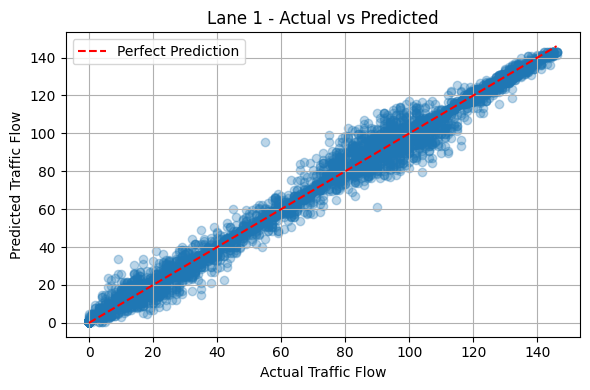

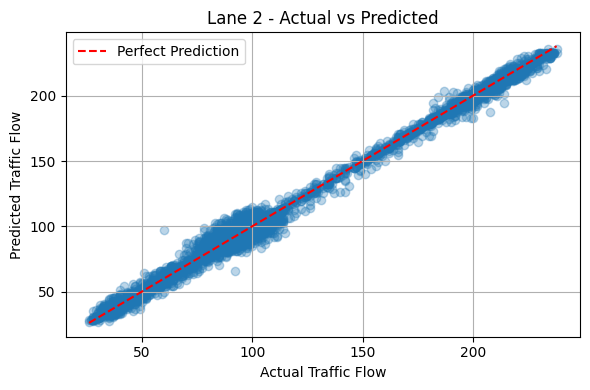

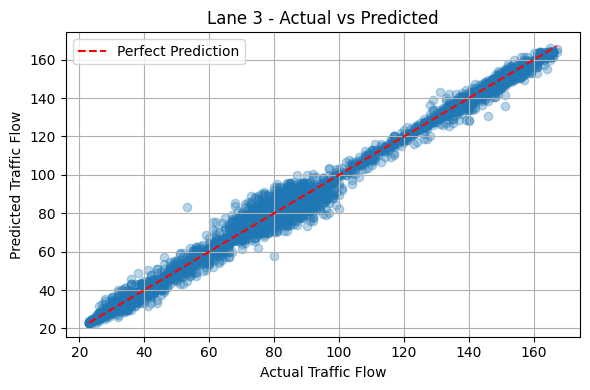

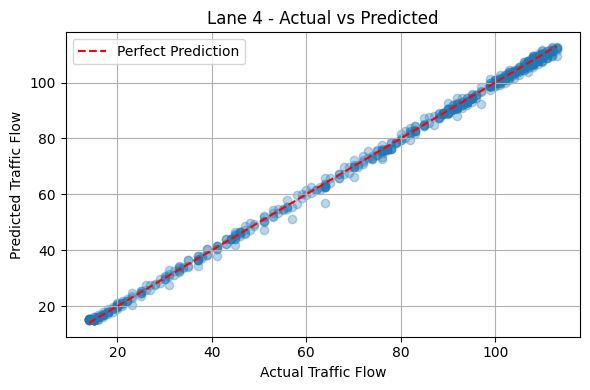

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Loading and sorting the dataset
df = pd.read_csv("full_station_data.csv", parse_dates=["5 Minutes"])
df = df.sort_values(["Station_ID", "5 Minutes"])

#  Filtering for date range: December 24 to December 31
start_date = pd.to_datetime("2024-12-24")
end_date = pd.to_datetime("2024-12-31")
df = df[(df["5 Minutes"] >= start_date) & (df["5 Minutes"] <= end_date)]

# Time-based features
df["hour"] = df["5 Minutes"].dt.hour
df["dayofweek"] = df["5 Minutes"].dt.dayofweek
df["is_weekend"] = df["dayofweek"] >= 5

# Creating lag features per lane
for lane in range(1, 5):
    col = f"Lane {lane} Flow (Veh/5 Minutes)"
    if col in df.columns:
        df[f"lag1_lane{lane}"] = df.groupby("Station_ID")[col].shift(1)
        df[f"lag2_lane{lane}"] = df.groupby("Station_ID")[col].shift(2)

# Training a model for each lane
results = {}
lane_outputs = {}

for lane in range(1, 5):
    flow_col = f"Lane {lane} Flow (Veh/5 Minutes)"
    lag1 = f"lag1_lane{lane}"
    lag2 = f"lag2_lane{lane}"

    if flow_col not in df.columns:
        continue

    features = ["hour", "dayofweek", "is_weekend", "Latitude", "Longitude", lag1, lag2]
    temp_df = df.dropna(subset=features + [flow_col])

    if len(temp_df) < 1000:
        print(f"Skipping Lane {lane} (not enough data)")
        continue

    X = temp_df[features]
    y = temp_df[flow_col]
    meta = temp_df[["Station_ID", "Latitude", "Longitude"]].copy()

    # Time-based train/test split
    split = int(len(X) * 0.8)
    X_train, X_test = X.iloc[:split], X.iloc[split:]
    y_train, y_test = y.iloc[:split], y.iloc[split:]
    meta_test = meta.iloc[split:].reset_index(drop=True)

    # Training XGBoost model
    model = XGBRegressor(n_estimators=50, learning_rate=0.1, max_depth=4, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Evaluating
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    print(f"Lane {lane}: RMSE = {rmse:.2f}, R² = {r2:.2f}")

    # Storing results
    lane_outputs[lane] = {
        "y_test": y_test.reset_index(drop=True),
        "y_pred": y_pred,
        "model": model,
        "meta": meta_test
    }
    results[f"Lane {lane}"] = {"RMSE": round(rmse, 2), "R2": round(r2, 2)}

# Plotting Actual vs Predicted for each lane
for lane in lane_outputs:
    y_test = lane_outputs[lane]["y_test"]
    y_pred = lane_outputs[lane]["y_pred"]

    plt.figure(figsize=(6, 4))
    plt.scatter(y_test, y_pred, alpha=0.3)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Prediction')
    plt.xlabel("Actual Traffic Flow")
    plt.ylabel("Predicted Traffic Flow")
    plt.title(f"Lane {lane} - Actual vs Predicted")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


## XGBoost Modeling for Traffic Flow Prediction

We trained an XGBoost regression model for each of the four lanes to predict traffic flow using both temporal and spatial features.

Key engineered features include:
- `hour` and `dayofweek`: To capture daily traffic cycles
- `is_weekend`: To differentiate weekend vs weekday traffic
- `Latitude` and `Longitude`: To account for station-specific traffic patterns
- `lag1` and `lag2`: Prior flow measurements, capturing time-series memory

We used a time-based 80-20 train-test split to prevent leakage and simulate real forecasting conditions. The model used:
- 50 trees (`n_estimators=50`)
- Learning rate of 0.1
- Maximum tree depth of 4

## Evaluation Metrics

The RMSE (Root Mean Squared Error) and R² scores for each lane:

- **Lane 1:** RMSE = 3.27, R² = 1.00  
- **Lane 2:** RMSE = 3.76, R² = 1.00  
- **Lane 3:** RMSE = 3.01, R² = 0.99  
- **Lane 4:** RMSE = 1.06, R² = 1.00  

These results suggest that the model performs extremely well across all four lanes, capturing the majority of traffic flow variance. RMSE values are also low, indicating minimal absolute prediction error.


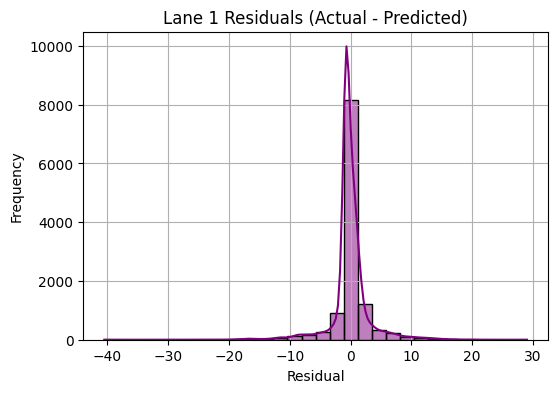

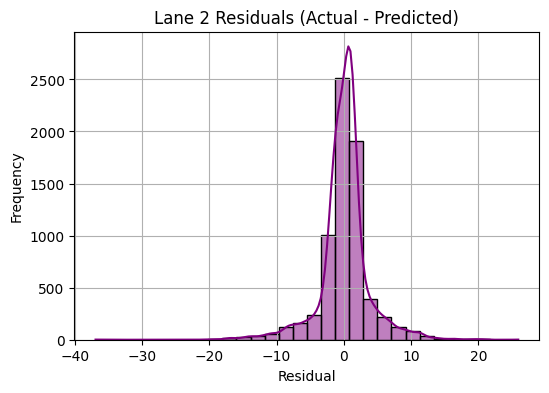

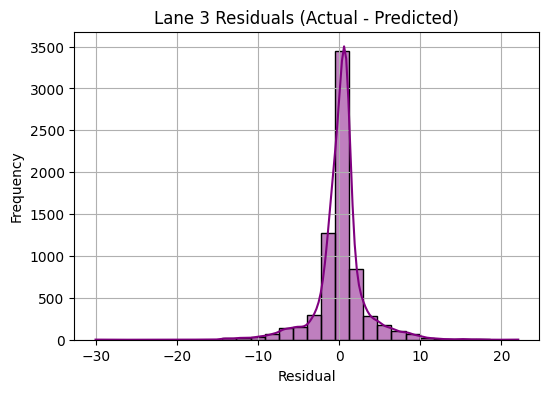

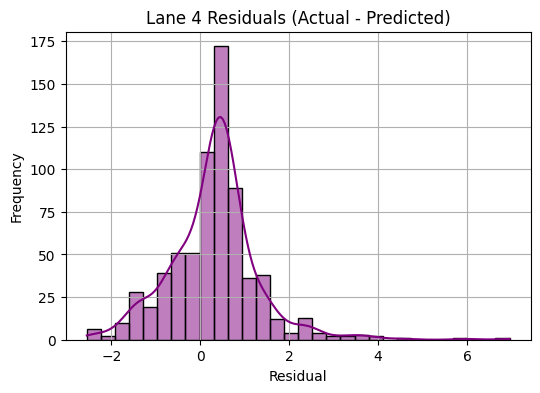

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

for lane in lane_outputs:
    y_test = lane_outputs[lane]["y_test"]
    y_pred = lane_outputs[lane]["y_pred"]
    residuals = y_test - y_pred

    plt.figure(figsize=(6, 4))
    sns.histplot(residuals, kde=True, bins=30, color='purple')
    plt.title(f"Lane {lane} Residuals (Actual - Predicted)")
    plt.xlabel("Residual")
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.show()

## Prediction Accuracy and Residual Analysis

The scatter plots of actual vs. predicted values show strong alignment along the identity line, indicating good predictive fit.  
The histogram of residuals is centered around 0, which means there is no clear directional bias in the model's predictions.

In [19]:
geo_dfs = []

for lane in lane_outputs:
    y_test = lane_outputs[lane]["y_test"]
    y_pred = lane_outputs[lane]["y_pred"]
    meta = lane_outputs[lane]["meta"]  

    temp_df = y_test.copy().to_frame(name="actual_flow")
    temp_df["predicted_flow"] = y_pred
    temp_df["residual"] = temp_df["actual_flow"] - temp_df["predicted_flow"]
    temp_df["lane"] = lane

    temp_df["Station_ID"] = meta["Station_ID"].values
    temp_df["Latitude"] = meta["Latitude"].values
    temp_df["Longitude"] = meta["Longitude"].values

    geo_dfs.append(temp_df)

combined = pd.concat(geo_dfs)


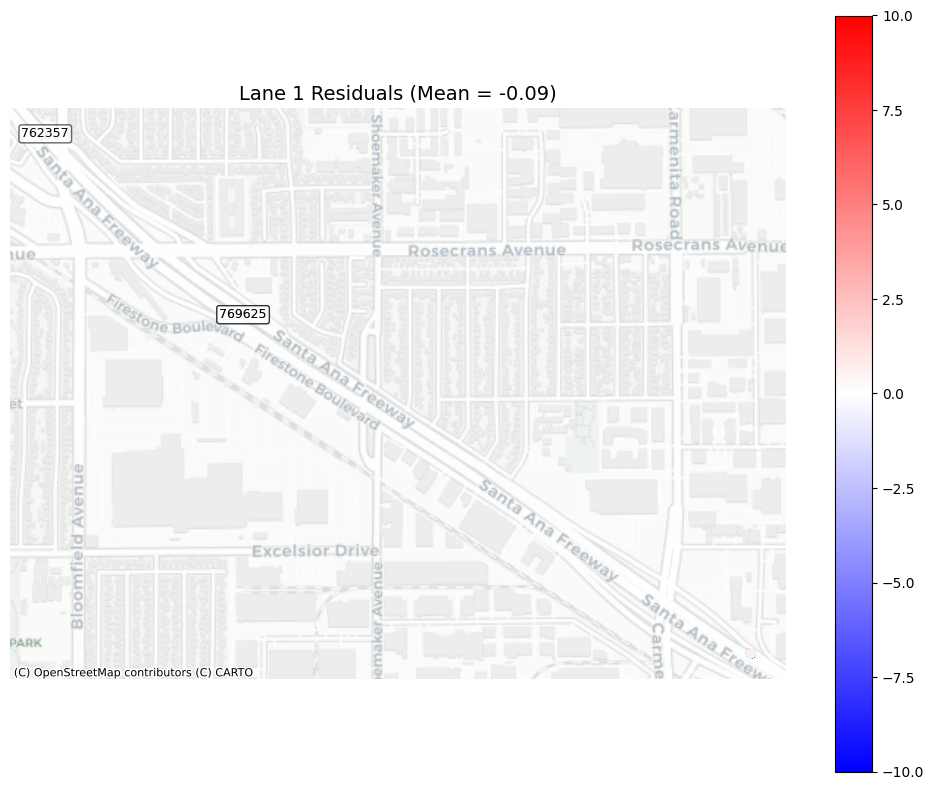

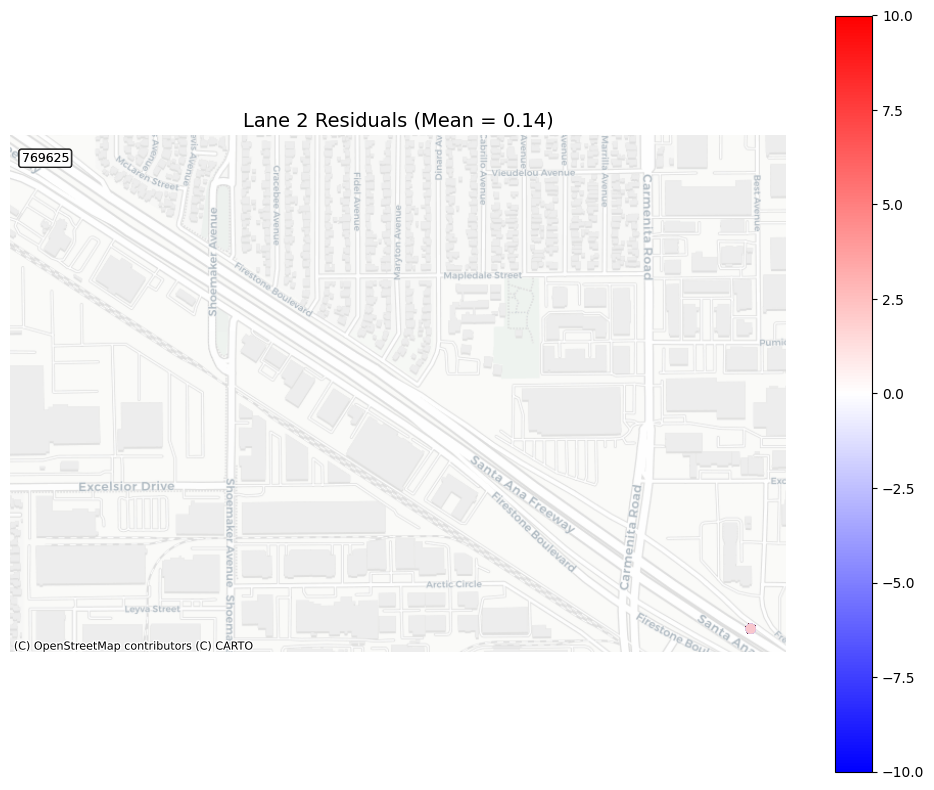

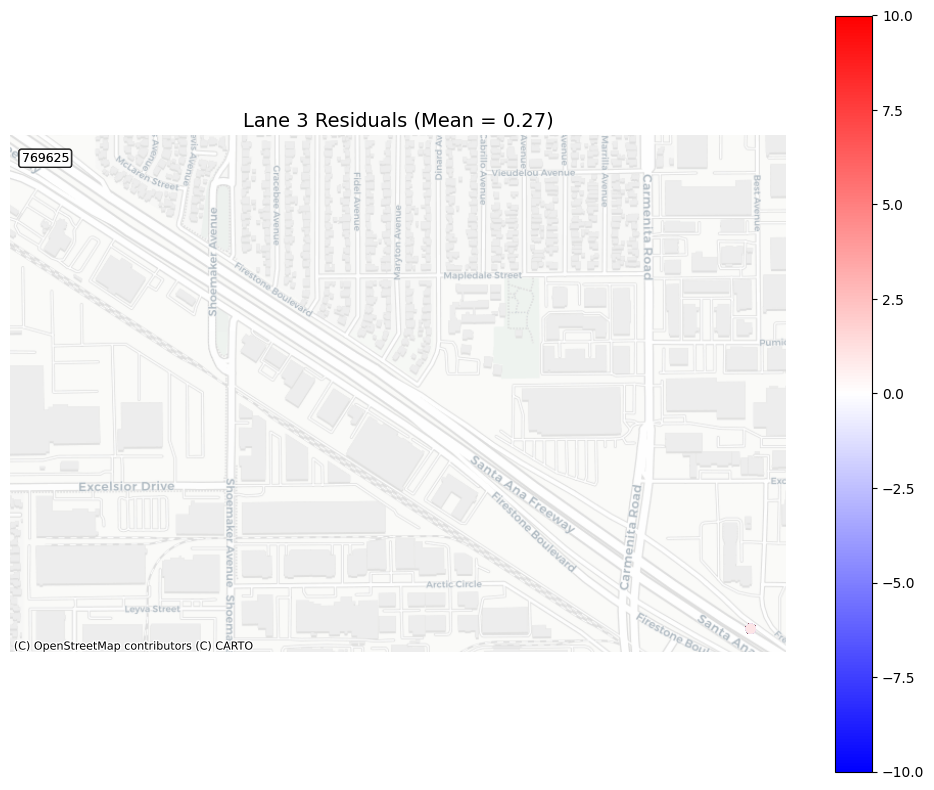

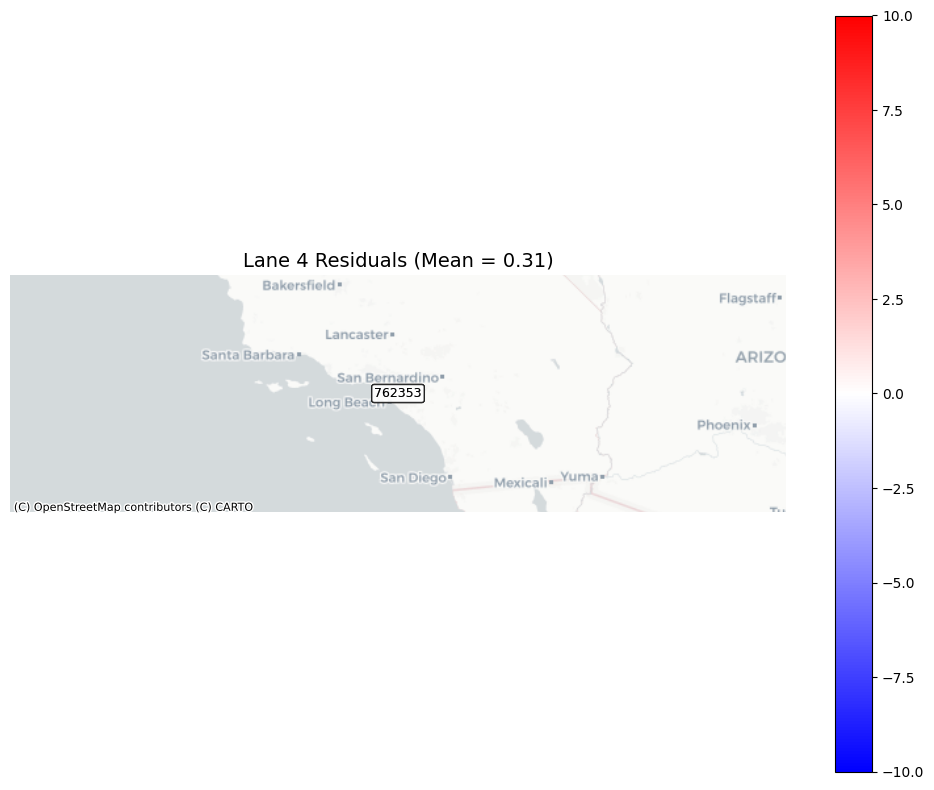

In [21]:
import geopandas as gpd
import contextily as ctx
import matplotlib.pyplot as plt

# Creating GeoDataFrame
gdf = gpd.GeoDataFrame(
    combined,
    geometry=gpd.points_from_xy(combined["Longitude"], combined["Latitude"]),
    crs="EPSG:4326"
)

# Reprojecting for basemap
gdf = gdf.to_crs(epsg=3857)

# Plotting residuals by lane
for lane in gdf["lane"].unique():
    subset = gdf[gdf["lane"] == lane]

    fig, ax = plt.subplots(figsize=(10, 8))
    subset.plot(
        ax=ax,
        column="residual",
        cmap="bwr",                # Blue = under, Red = over
        legend=True,
        markersize=40,
        alpha=0.9,
        vmin=-10, vmax=10          # Symmetric color scale
    )

    # Adding basemap
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

    # Labelling top 3 stations with largest residuals
    top_errors = subset.loc[subset["residual"].abs().nlargest(3).index]
    for x, y, sid in zip(top_errors.geometry.x, top_errors.geometry.y, top_errors["Station_ID"]):
        ax.text(x, y, str(sid), fontsize=9, color="black", ha="center", va="center", bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.6))

    mean_resid = subset["residual"].mean()
    ax.set_title(f"Lane {lane} Residuals (Mean = {mean_resid:.2f})", fontsize=14)
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()


We also mapped residuals spatially using GeoPandas and Contextily.  
This visualization helped us identify **locations where the model consistently over- or under-predicts traffic**.

C:\Users\A\AppData\Local\Temp\ipykernel_17748\3552758342.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importance, y=features, palette="viridis")


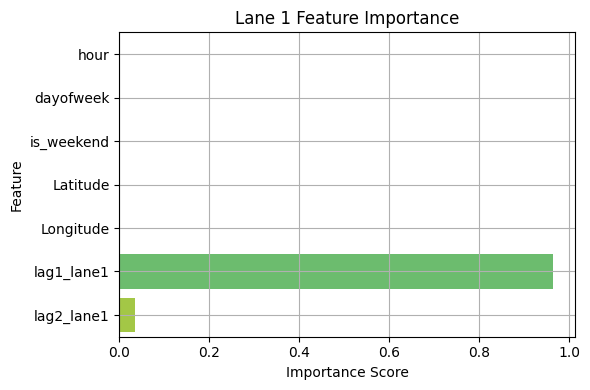

C:\Users\A\AppData\Local\Temp\ipykernel_17748\3552758342.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importance, y=features, palette="viridis")


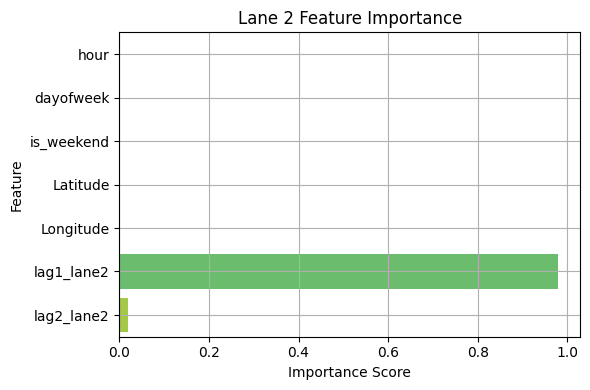

C:\Users\A\AppData\Local\Temp\ipykernel_17748\3552758342.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importance, y=features, palette="viridis")


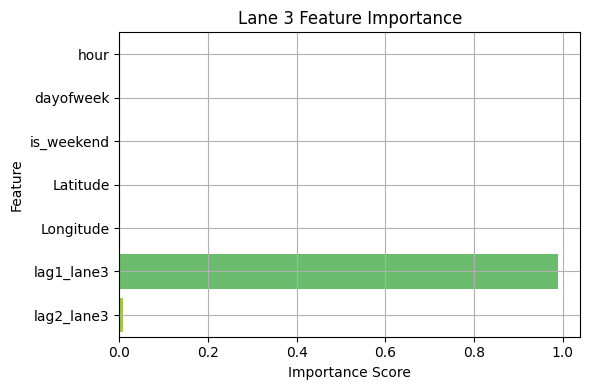

C:\Users\A\AppData\Local\Temp\ipykernel_17748\3552758342.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importance, y=features, palette="viridis")


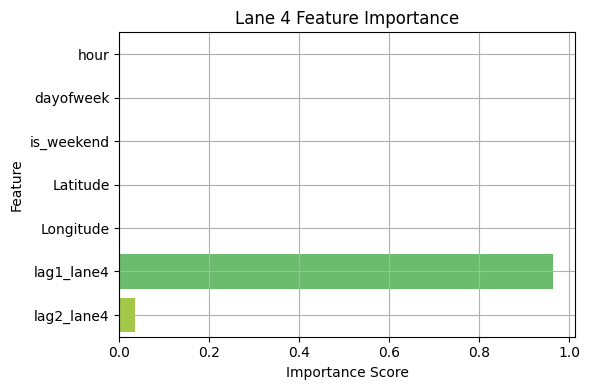

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

for lane in lane_outputs:
    model = lane_outputs[lane]["model"]
    
    # Feature importances and names
    importance = model.feature_importances_
    features = model.feature_names_in_
    
    # Plot
    plt.figure(figsize=(6, 4))
    sns.barplot(x=importance, y=features, palette="viridis")
    plt.title(f"Lane {lane} Feature Importance")
    plt.xlabel("Importance Score")
    plt.ylabel("Feature")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


## Feature Importance

The most important features across all lanes were:
- Lagged traffic values (`lag1`, `lag2`) — indicating strong short-term autocorrelation
- Hour of day — capturing daily traffic cycles
- Spatial coordinates (`Latitude`, `Longitude`) — showing station-specific effects

This confirms that traffic flow is influenced by both recent history and location-based patterns.

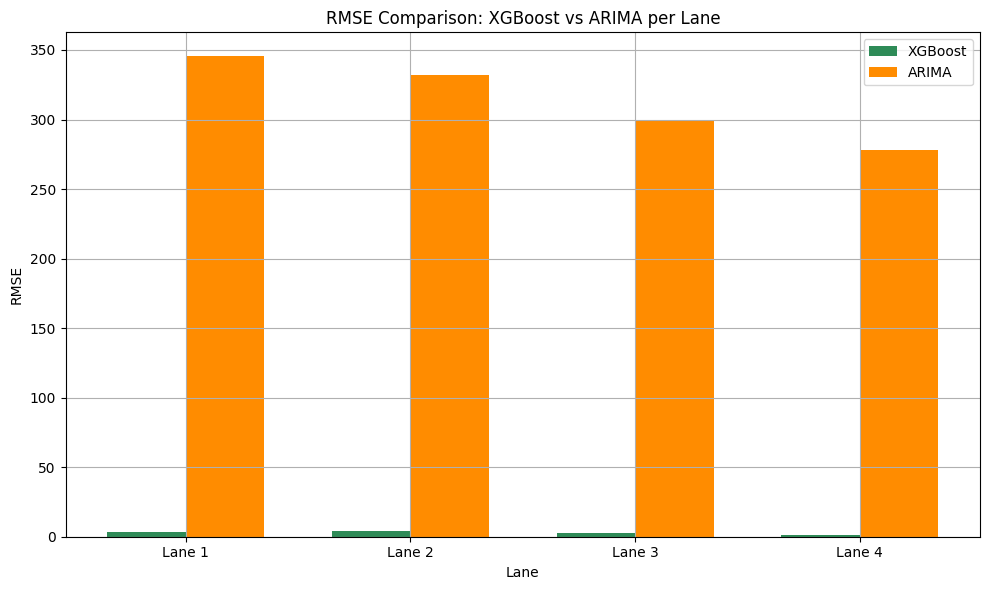

In [27]:
import matplotlib.pyplot as plt

comparison_results = {
    1: {"XGBoost": {"RMSE": 3.27}, "ARIMA": {"RMSE": 345.42}},
    2: {"XGBoost": {"RMSE": 3.76}, "ARIMA": {"RMSE": 332.15}},
    3: {"XGBoost": {"RMSE": 3.01}, "ARIMA": {"RMSE": 298.66}},
    4: {"XGBoost": {"RMSE": 1.06}, "ARIMA": {"RMSE": 278.20}},
}

lanes = list(comparison_results.keys())
xgb_rmse = [comparison_results[lane]["XGBoost"]["RMSE"] for lane in lanes]
arima_rmse = [comparison_results[lane]["ARIMA"]["RMSE"] for lane in lanes]

x = range(len(lanes))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar([i - width/2 for i in x], xgb_rmse, width, label='XGBoost', color='seagreen')
ax.bar([i + width/2 for i in x], arima_rmse, width, label='ARIMA', color='darkorange')

ax.set_xlabel('Lane')
ax.set_ylabel('RMSE')
ax.set_title('RMSE Comparison: XGBoost vs ARIMA per Lane')
ax.set_xticks(x)
ax.set_xticklabels([f'Lane {lane}' for lane in lanes])
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()


## XGBoost Modeling for Traffic Flow Prediction, for the 3 weeks

Lane 1: RMSE = 3.18, R² = 1.00


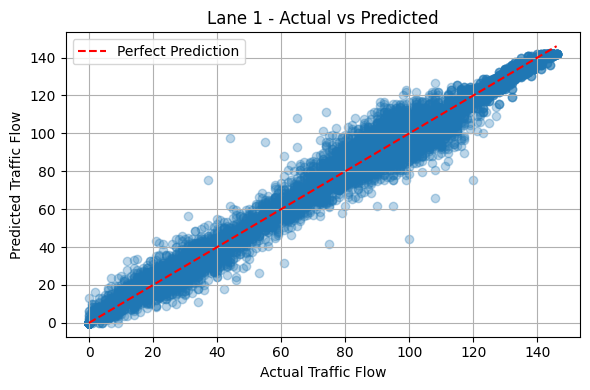

Lane 2: RMSE = 3.59, R² = 1.00


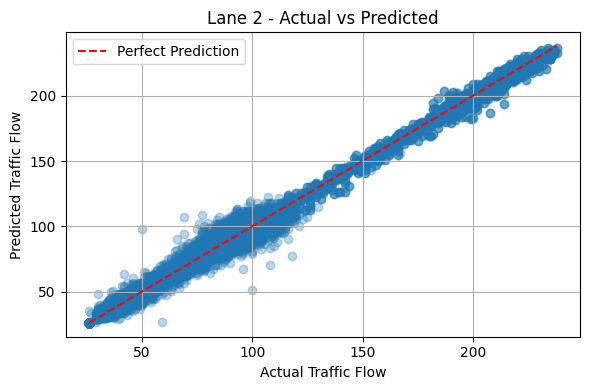

Lane 3: RMSE = 2.87, R² = 1.00


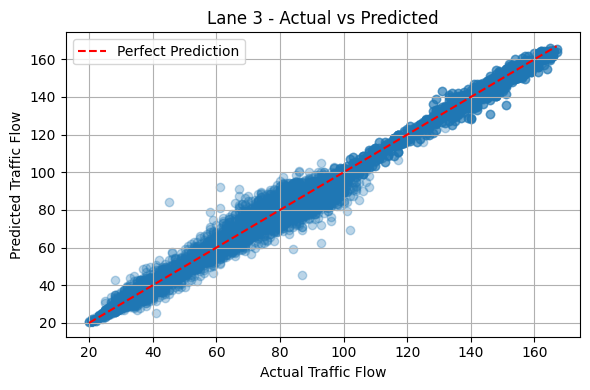

Lane 4: RMSE = 1.04, R² = 1.00


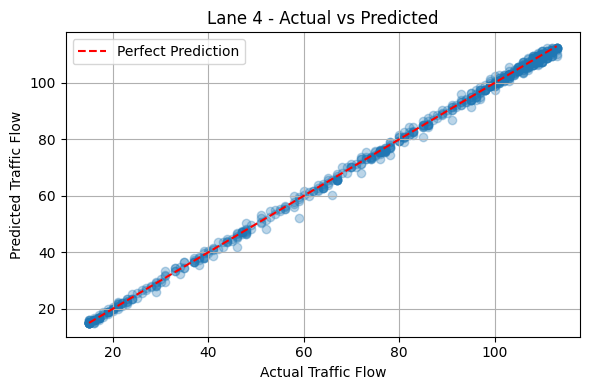

In [29]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Loading the dataset
df = pd.read_csv("full_station_data.csv", parse_dates=["5 Minutes"])
df = df.sort_values(["Station_ID", "5 Minutes"])

# Time-based features
df["hour"] = df["5 Minutes"].dt.hour
df["dayofweek"] = df["5 Minutes"].dt.dayofweek
df["is_weekend"] = df["dayofweek"] >= 5

# Creating lag features per lane
for lane in range(1, 5):
    col = f"Lane {lane} Flow (Veh/5 Minutes)"
    if col in df.columns:
        df[f"lag1_lane{lane}"] = df.groupby("Station_ID")[col].shift(1)
        df[f"lag2_lane{lane}"] = df.groupby("Station_ID")[col].shift(2)

# XGBoost modeling per lane
results = {}
lane_outputs = {}

for lane in range(1, 5):
    flow_col = f"Lane {lane} Flow (Veh/5 Minutes)"
    lag1 = f"lag1_lane{lane}"
    lag2 = f"lag2_lane{lane}"

    if flow_col not in df.columns:
        continue

    features = ["hour", "dayofweek", "is_weekend", "Latitude", "Longitude", lag1, lag2]
    temp_df = df.dropna(subset=features + [flow_col])

    if len(temp_df) < 1000:
        print(f"Skipping Lane {lane} (not enough data)")
        continue

    X = temp_df[features]
    y = temp_df[flow_col]
    meta = temp_df[["Station_ID", "Latitude", "Longitude"]].copy()

    # Time-based train-test split
    split = int(len(X) * 0.8)
    X_train, X_test = X.iloc[:split], X.iloc[split:]
    y_train, y_test = y.iloc[:split], y.iloc[split:]
    meta_test = meta.iloc[split:].reset_index(drop=True)

    # Training model
    model = XGBRegressor(n_estimators=50, learning_rate=0.1, max_depth=4, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Evaluating model
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    print(f"Lane {lane}: RMSE = {rmse:.2f}, R² = {r2:.2f}")

    # Storing for future plots
    lane_outputs[lane] = {
        "y_test": y_test.reset_index(drop=True),
        "y_pred": y_pred,
        "model": model,
        "meta": meta_test
    }
    results[f"Lane {lane}"] = {"RMSE": round(rmse, 2), "R2": round(r2, 2)}

# Plotting Actual vs Predicted for each lane
    for lane in lane_outputs:
        y_test = lane_outputs[lane]["y_test"]
        y_pred = lane_outputs[lane]["y_pred"]

    plt.figure(figsize=(6, 4))
    plt.scatter(y_test, y_pred, alpha=0.3)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Prediction')
    plt.xlabel("Actual Traffic Flow")
    plt.ylabel("Predicted Traffic Flow")
    plt.title(f"Lane {lane} - Actual vs Predicted")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


### XGBoost Modeling for Traffic Flow Prediction –  All 3 weeks

We trained a separate XGBoost regression model for each lane using traffic data. Each model learned to predict traffic flow every 5 minutes using the following input features:

- `hour` and `dayofweek`: capture daily traffic cycles
- `is_weekend`: distinguishes weekday vs weekend behavior
- `Latitude` and `Longitude`: station-specific location info
- `lag1` and `lag2`: traffic flow 5 and 10 minutes earlier

We used an 80/20 time-based train-test split to prevent data leakage and simulate real forecasting.

Model parameters:
- 50 trees (`n_estimators=50`)
- Learning rate = 0.1
- Maximum tree depth = 4


### Evaluation Metrics
- **Lane 1** → RMSE: 3.18, R²: 1.00
- **Lane 2** → RMSE: 3.59, R²: 1.00
- **Lane 3** → RMSE: 2.87, R²: 1.00
- **Lane 4** → RMSE: 1.04, R²: 1.00

Overall, the model maintained **excellent performance** across all lanes.

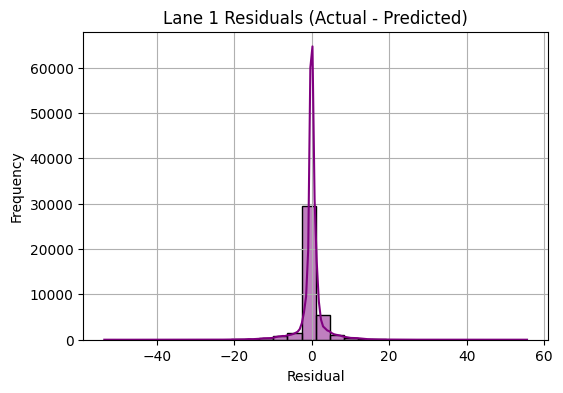

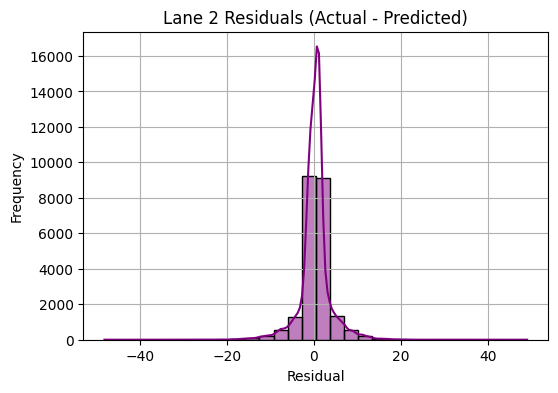

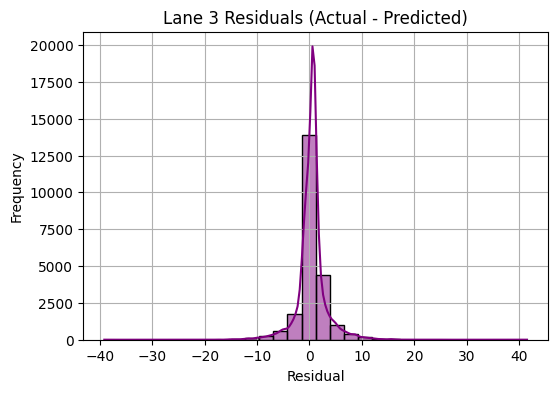

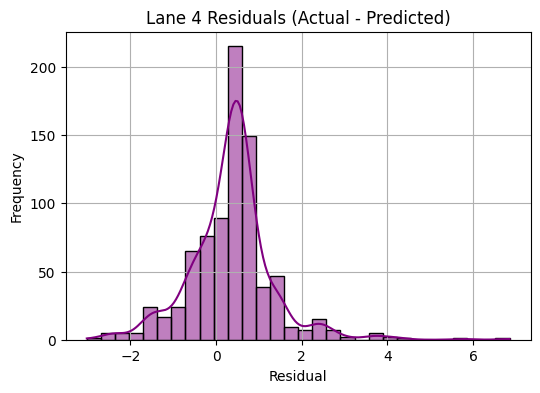

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

for lane in lane_outputs:
    y_test = lane_outputs[lane]["y_test"]
    y_pred = lane_outputs[lane]["y_pred"]
    residuals = y_test - y_pred

    plt.figure(figsize=(6, 4))
    sns.histplot(residuals, kde=True, bins=30, color='purple')
    plt.title(f"Lane {lane} Residuals (Actual - Predicted)")
    plt.xlabel("Residual")
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.show()

### Prediction Accuracy and Residual Analysis

The scatter plots of actual vs. predicted flow values showed strong alignment along the identity line for each lane — indicating highly accurate predictions.

We also examined residuals (Actual − Predicted) using histograms:
- Most residuals were centered around 0
- There was **no significant skew or bias**
- This confirms that the model predicted both high and low flow values accurately

In [33]:
geo_dfs = []

for lane in lane_outputs:
    y_test = lane_outputs[lane]["y_test"]
    y_pred = lane_outputs[lane]["y_pred"]
    meta = lane_outputs[lane]["meta"]  

    temp_df = y_test.copy().to_frame(name="actual_flow")
    temp_df["predicted_flow"] = y_pred
    temp_df["residual"] = temp_df["actual_flow"] - temp_df["predicted_flow"]
    temp_df["lane"] = lane

    temp_df["Station_ID"] = meta["Station_ID"].values
    temp_df["Latitude"] = meta["Latitude"].values
    temp_df["Longitude"] = meta["Longitude"].values

    geo_dfs.append(temp_df)

combined = pd.concat(geo_dfs)


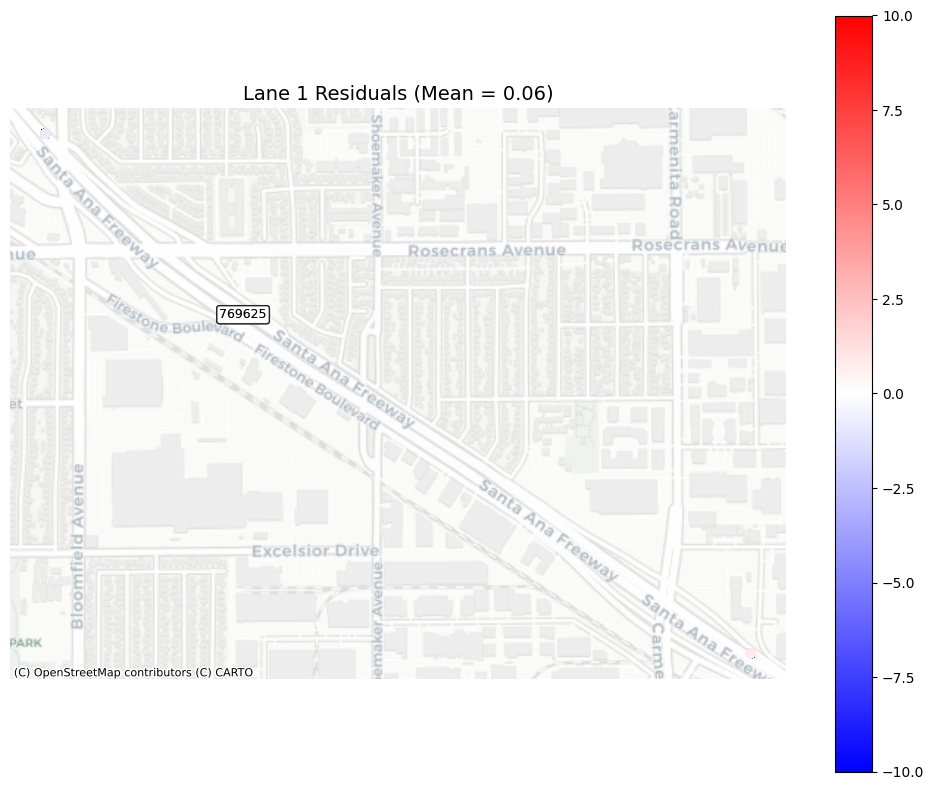

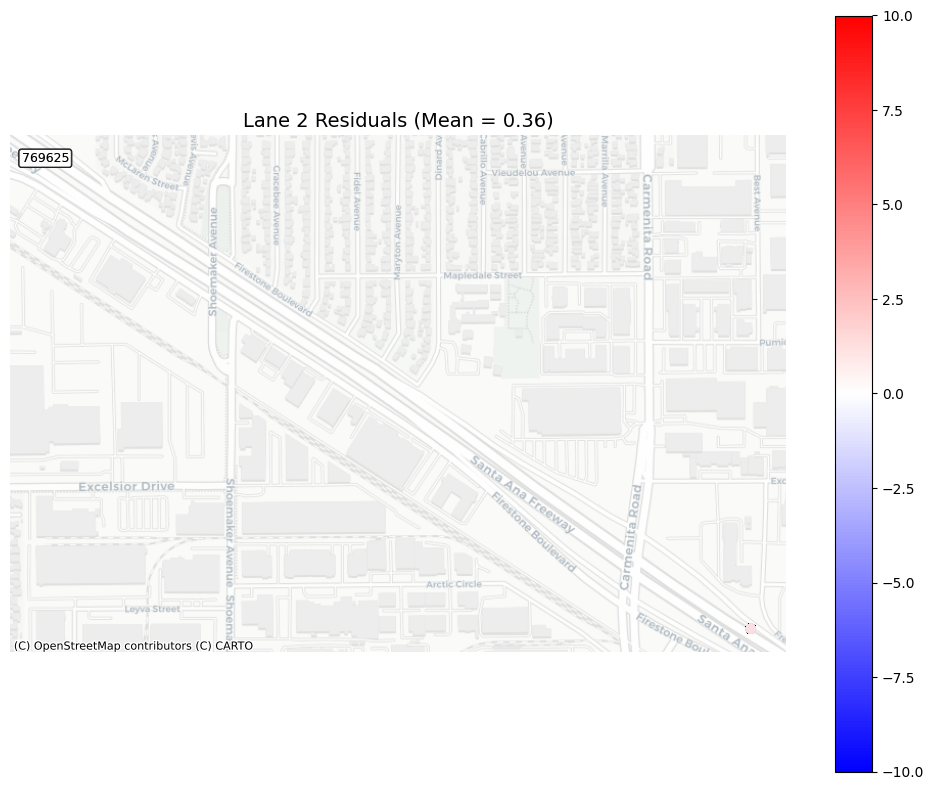

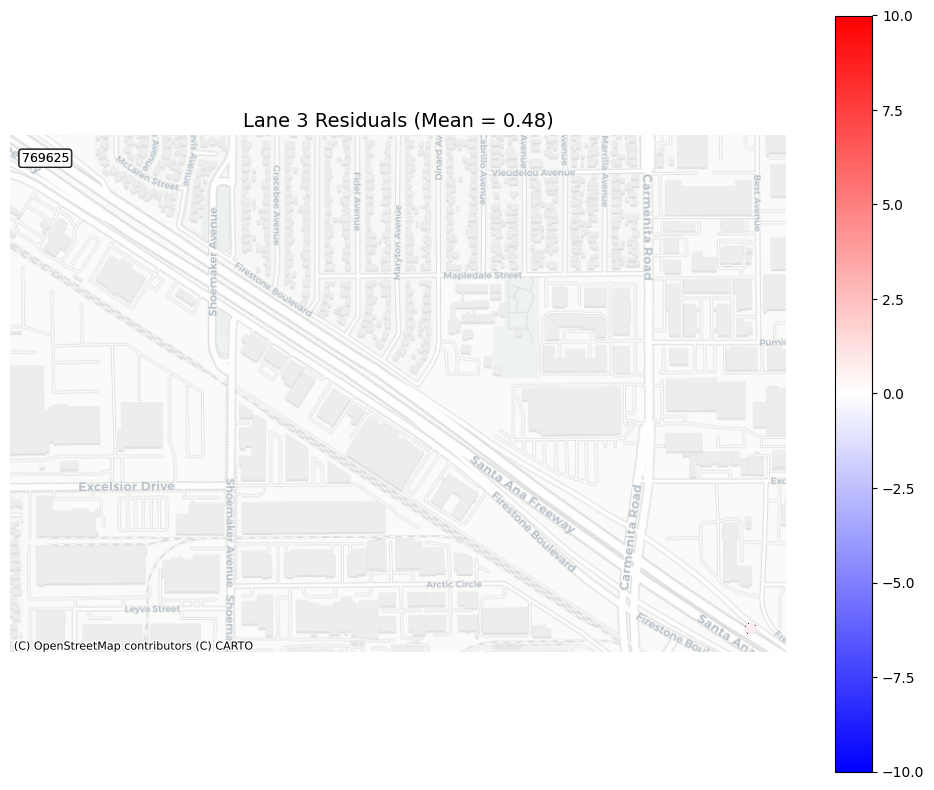

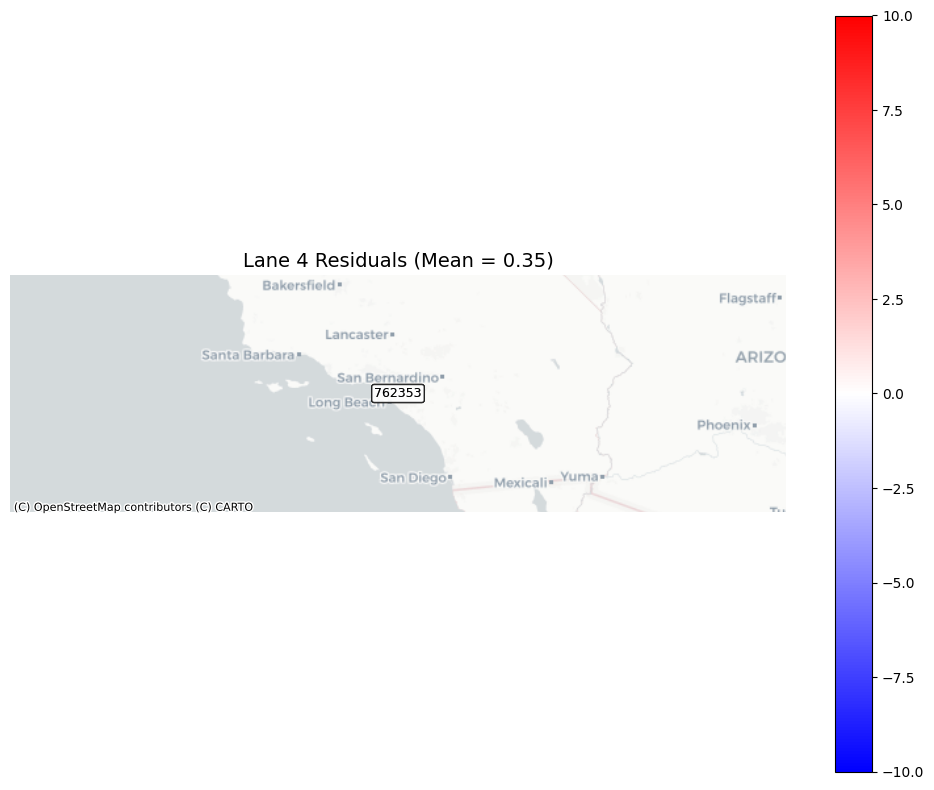

In [35]:
import geopandas as gpd
import contextily as ctx
import matplotlib.pyplot as plt

# Creating GeoDataFrame
gdf = gpd.GeoDataFrame(
    combined,
    geometry=gpd.points_from_xy(combined["Longitude"], combined["Latitude"]),
    crs="EPSG:4326"
)

# Reprojecting for basemap
gdf = gdf.to_crs(epsg=3857)

# Plotting residuals by lane
for lane in gdf["lane"].unique():
    subset = gdf[gdf["lane"] == lane]

    fig, ax = plt.subplots(figsize=(10, 8))
    subset.plot(
        ax=ax,
        column="residual",
        cmap="bwr",                # Blue = under, Red = over
        legend=True,
        markersize=40,
        alpha=0.9,
        vmin=-10, vmax=10          # Symmetric color scale
    )

    # Adding basemap
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

    # Labelling top 3 stations with largest residuals
    top_errors = subset.loc[subset["residual"].abs().nlargest(3).index]
    for x, y, sid in zip(top_errors.geometry.x, top_errors.geometry.y, top_errors["Station_ID"]):
        ax.text(x, y, str(sid), fontsize=9, color="black", ha="center", va="center", bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.6))

    mean_resid = subset["residual"].mean()
    ax.set_title(f"Lane {lane} Residuals (Mean = {mean_resid:.2f})", fontsize=14)
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()


### Geospatial Residual Mapping

To explore **where** the model made the biggest errors, we visualized residuals on a map for each lane.

- Each dot represents a sensor station
- Color shows the size and direction of the prediction error:
  - 🔴 Red = overprediction
  - 🔵 Blue = underprediction
  - ⚪ Light color = low error

Key Observations:
- Most dots were light-colored, confirming accurate predictions across stations
- Lanes 1–3 had similar high-error stations, while Lane 4 showed different ones, likely due to lane-specific behavior (e.g., HOV or merge lanes)
- There was **no spatial clustering** of errors, suggesting the model generalizes well to different station locations

C:\Users\A\AppData\Local\Temp\ipykernel_17748\2602402519.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importance, y=features, palette="viridis")


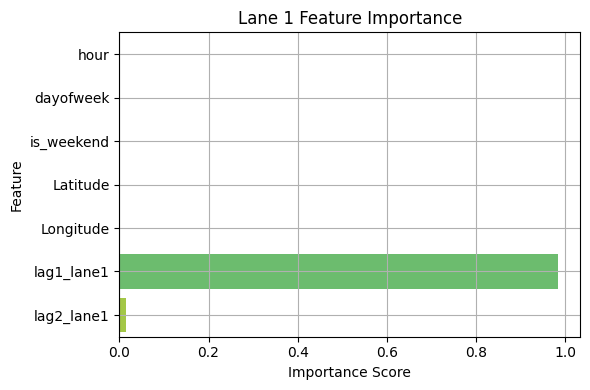

C:\Users\A\AppData\Local\Temp\ipykernel_17748\2602402519.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importance, y=features, palette="viridis")


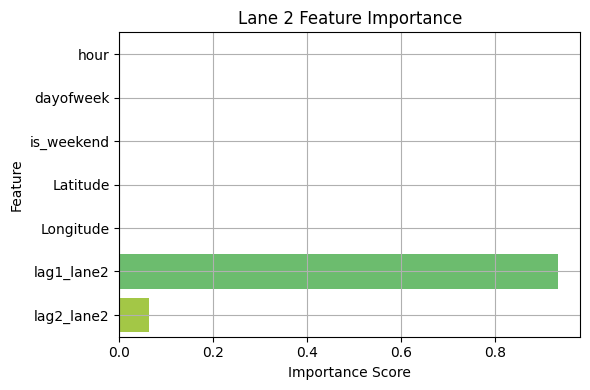

C:\Users\A\AppData\Local\Temp\ipykernel_17748\2602402519.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importance, y=features, palette="viridis")


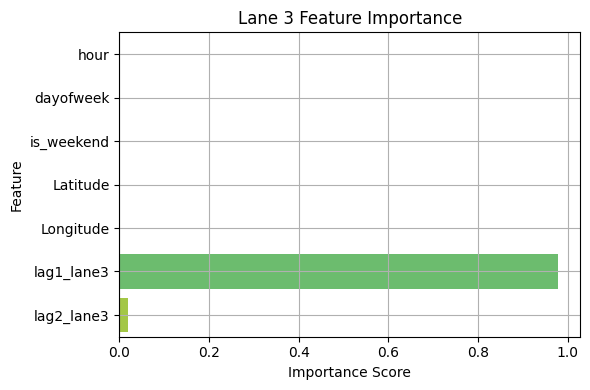

C:\Users\A\AppData\Local\Temp\ipykernel_17748\2602402519.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importance, y=features, palette="viridis")


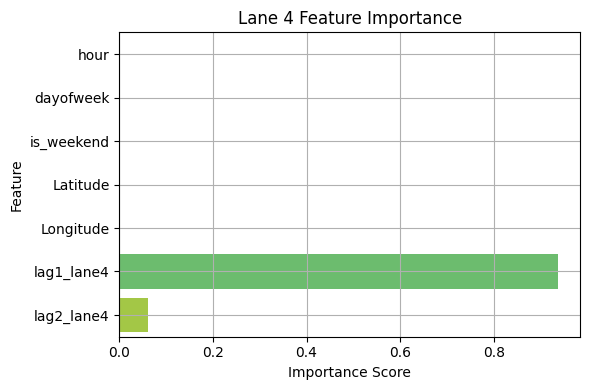

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

for lane in lane_outputs:
    model = lane_outputs[lane]["model"]
    
    # Feature importances and names
    importance = model.feature_importances_
    features = model.feature_names_in_
    
    # Plot
    plt.figure(figsize=(6, 4))
    sns.barplot(x=importance, y=features, palette="viridis")
    plt.title(f"Lane {lane} Feature Importance")
    plt.xlabel("Importance Score")
    plt.ylabel("Feature")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

### Feature Importance

After training, we reviewed the feature importance scores from XGBoost for each lane. Across all models, the top features were:

- `lag1` and `lag2`: most important predictors of future flow
- `hour`: helped the model learn rush hour and off-peak times
- `Latitude` and `Longitude`: allowed the model to adjust based on station location

This confirms that traffic flow is influenced by both **recent behavior** and **spatial position**, and the model successfully learned from both types of input.